# 🛒 Capstone 2 E-Commerce Customer Churn Prediction
---
**Pipeline:** Data Cleaning → Data Preprocessing → Hyperparameter Tuning → Final Evaluation

**Dataset:** `data_ecommerce_customer_churn.csv`

**Target Variable:** `Churn` (0 = Tidak Churn, 1 = Churn)

## 📦 Import Library

In [1]:
# Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV

# Imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)


print('✅ Semua library berhasil diimport!')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')

✅ Semua library berhasil diimport!
Pandas  : 3.0.0
NumPy   : 2.4.2


In [2]:
!pip install imbalanced-learn xgboost -q

## 📂 Load Dataset

In [3]:
df_raw = pd.read_csv('data_ecommerce_customer_churn.csv')
df = df_raw.copy()

print(f'Shape dataset: {df.shape}')
print(f'Jumlah baris : {df.shape[0]:,}')
print(f'Jumlah kolom : {df.shape[1]}')
df.head(10)

Shape dataset: (3941, 11)
Jumlah baris : 3,941
Jumlah kolom : 11


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
5,7.0,16.0,4,Mobile Phone,2,Divorced,2,0,11.0,152.81,0
6,1.0,15.0,6,Mobile Phone,5,Divorced,3,0,2.0,149.51,0
7,1.0,11.0,4,Mobile Phone,5,Single,3,0,1.0,154.73,1
8,11.0,12.0,4,Mobile Phone,3,Married,2,0,4.0,137.02,0
9,17.0,7.0,3,Laptop & Accessory,1,Married,5,1,2.0,157.43,0


In [4]:
# Info tipe data dan memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   str    
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   str    
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 338.8 KB


In [5]:
# Statistik deskriptif
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Tenure,3747.0,NaN,NaN,NaN,10.081398,8.498864,0.0,2.0,9.0,16.0,61.0
WarehouseToHome,3772.0,NaN,NaN,NaN,15.650583,8.452301,5.0,9.0,14.0,21.0,127.0
NumberOfDeviceRegistered,3941.0,NaN,NaN,NaN,3.679269,1.013938,1.0,3.0,4.0,4.0,6.0
PreferedOrderCat,3941,6,Laptop & Accessory,1458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SatisfactionScore,3941.0,NaN,NaN,NaN,3.088302,1.381832,1.0,2.0,3.0,4.0,5.0
MaritalStatus,3941,3,Married,2055,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfAddress,3941.0,NaN,NaN,NaN,4.237757,2.626699,1.0,2.0,3.0,6.0,22.0
Complain,3941.0,NaN,NaN,NaN,0.282416,0.450232,0.0,0.0,0.0,1.0,1.0
DaySinceLastOrder,3728.0,NaN,NaN,NaN,4.531652,3.667648,0.0,2.0,3.0,7.0,46.0
CashbackAmount,3941.0,NaN,NaN,NaN,176.707419,48.791784,0.0,145.7,163.34,195.25,324.99


---
# 🧹 BAGIAN 1 — DATA CLEANING

## 1.1 Missing Values

> **Mengapa penanganan *missing values* harus dilakukan pertama?**
>
> *Missing values* (nilai yang kosong/NaN) adalah salah satu masalah paling umum dalam data dunia nyata. Jika dibiarkan:
>
> - Sebagian besar algoritma machine learning **tidak dapat memproses** data dengan NaN dan akan menghasilkan error
> - Dapat **menyebabkan bias** pada analisis statistik dan model prediktif
> - Mengurangi jumlah data jika kita memilih menghapus baris yang mengandung NaN
>
> **Langkah deteksi dulu** — kita perlu tahu *berapa banyak* dan *kolom mana* yang memiliki missing values sebelum memutuskan strategi penanganannya. Visualisasi bar chart membantu memprioritaskan kolom yang paling bermasalah.

=== MISSING VALUES SEBELUM IMPUTASI ===
                   Jumlah Missing  Persentase (%)
DaySinceLastOrder             213            5.40
Tenure                        194            4.92
WarehouseToHome               169            4.29


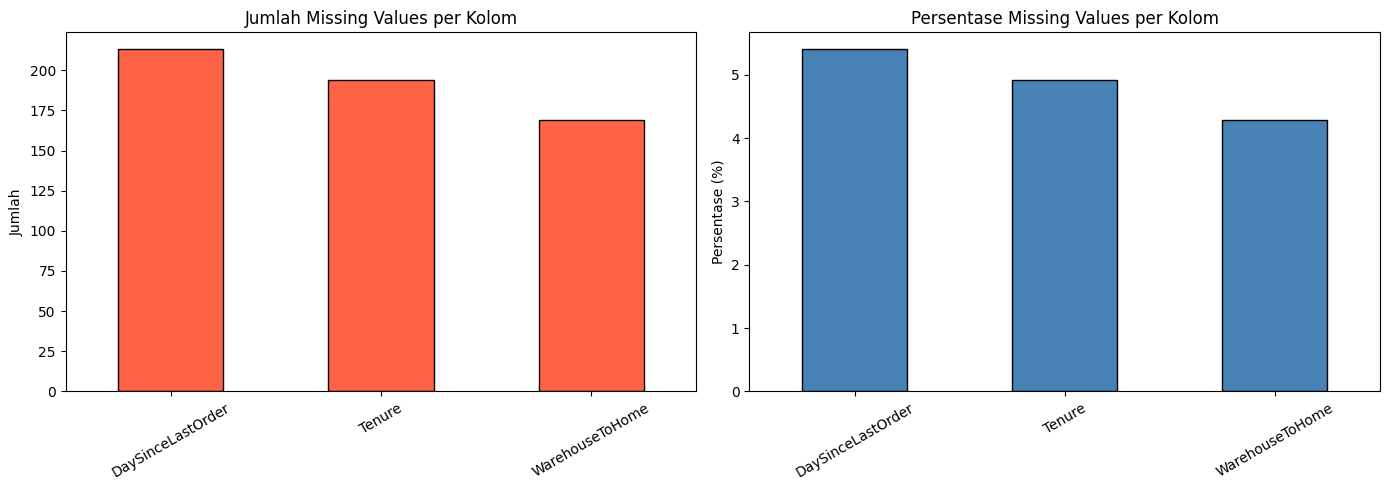

In [6]:
# --- Deteksi missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct.round(2)
}).query('`Jumlah Missing` > 0').sort_values('Jumlah Missing', ascending=False)

print('=== MISSING VALUES SEBELUM IMPUTASI ===')
print(missing_df)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

missing_df['Jumlah Missing'].plot(kind='bar', ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('Jumlah Missing Values per Kolom')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=30)

missing_df['Persentase (%)'].plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Persentase Missing Values per Kolom')
axes[1].set_ylabel('Persentase (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

> **Mengapa menggunakan median untuk imputasi, bukan mean (rata-rata)?**
>
> Strategi imputasi yang dipilih sangat mempengaruhi kualitas data:
>
> - **Median** dipilih untuk kolom **numerik** karena *robust* terhadap outlier. Jika data memiliki nilai ekstrem, mean akan tertarik ke arah outlier, sedangkan median tidak
> - **Modus** (nilai yang paling sering muncul) dipilih untuk kolom **kategorikal** karena tidak ada konsep rata-rata untuk kategori
>
> Imputasi dengan median memastikan distribusi data tidak terdistorsi oleh nilai-nilai ekstrem yang mungkin ada di dataset.

In [7]:
# --- Imputasi Missing Values ---
# Kolom numerik: isi dengan median (lebih robust terhadap outlier)
numeric_cols_with_na = df.select_dtypes(include='number').columns[df.select_dtypes(include='number').isnull().any()].tolist()

for col in numeric_cols_with_na:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f'  ✔ Kolom [{col}] → diisi median = {median_val}')

# Kolom kategorik: isi dengan modus
cat_cols_with_na = df.select_dtypes(include='object').columns[df.select_dtypes(include='object').isnull().any()].tolist()

for col in cat_cols_with_na:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f'  ✔ Kolom [{col}] → diisi modus = {mode_val}')

print(f'\n✅ Total missing setelah imputasi: {df.isnull().sum().sum()}')

  ✔ Kolom [Tenure] → diisi median = 9.0
  ✔ Kolom [WarehouseToHome] → diisi median = 14.0
  ✔ Kolom [DaySinceLastOrder] → diisi median = 3.0

✅ Total missing setelah imputasi: 576


## 1.2 Duplicate Data

> **Mengapa baris duplikat berbahaya untuk model machine learning?**
>
> Baris duplikat adalah baris yang memiliki nilai identik di semua kolom. Keberadaannya menyebabkan:
>
> - **Bias pada model** — model cenderung lebih menghafal pola dari baris yang muncul berulang, sehingga overfit pada data tersebut
> - **Evaluasi tidak akurat** — jika baris duplikat tersebar di training dan test set, model terlihat lebih baik dari seharusnya
> - **Distorsi distribusi** — frekuensi kemunculan nilai tertentu menjadi tidak representatif
>
> Kita deteksi dulu untuk mengetahui seberapa banyak duplikat sebelum memutuskan untuk menghapusnya.

In [8]:
# --- Deteksi duplikat ---
n_dup = df.duplicated().sum()
print(f'Jumlah baris duplikat : {n_dup}')
print(f'Persentase duplikat   : {n_dup/len(df)*100:.2f}%')

if n_dup > 0:
    print('\nContoh baris duplikat:')
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10))

Jumlah baris duplikat : 671
Persentase duplikat   : 17.03%

Contoh baris duplikat:


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
2974,0.0,6.0,3,Laptop & Accessory,4,Married,2,0,4.0,163.97,0
3576,0.0,6.0,3,Laptop & Accessory,4,Married,2,0,4.0,163.97,0
300,0.0,6.0,3,Mobile,4,Single,2,1,4.0,132.02,1
575,0.0,6.0,3,Mobile,4,Single,2,1,4.0,132.02,1
1364,0.0,6.0,4,Mobile,4,Single,2,0,0.0,128.36,0
2821,0.0,6.0,4,Mobile,4,Single,2,0,0.0,128.36,0
640,0.0,6.0,4,Mobile Phone,3,Single,1,1,2.0,137.30,1
3333,0.0,6.0,4,Mobile Phone,3,Single,1,1,2.0,137.30,1
767,0.0,8.0,1,Laptop & Accessory,3,Married,2,0,7.0,152.06,0
1696,0.0,8.0,1,Laptop & Accessory,3,Married,2,0,7.0,152.06,0


> **Mengapa kita melakukan `reset_index` setelah drop duplikat?**
>
> Setelah `drop_duplicates()`, indeks DataFrame menjadi tidak berurutan (ada lubang pada nomor indeks). `reset_index(drop=True)` penting karena:
>
> - Membuat indeks kembali berurutan dari 0 — mencegah masalah pada operasi berbasis indeks
> - `drop=True` memastikan indeks lama tidak disimpan sebagai kolom baru
> - Beberapa fungsi pandas dan sklearn bergantung pada indeks yang bersih dan berurutan

In [9]:
# --- Drop duplikat ---
df_before = df.shape[0]
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Baris sebelum drop duplikat : {df_before:,}')
print(f'Baris setelah drop duplikat : {df.shape[0]:,}')
print(f'Baris yang dihapus          : {df_before - df.shape[0]:,}')

Baris sebelum drop duplikat : 3,941
Baris setelah drop duplikat : 3,270
Baris yang dihapus          : 671


## 1.3 Inconsistent Data

> **Mengapa inkonsistensi data bisa merusak model?**
>
> Data kategorikal sering mengandung inkonsistensi yang tidak terlihat secara kasat mata, misalnya:
>
> - Perbedaan huruf besar/kecil: `mobile` vs `Mobile` vs `MOBILE` — dianggap 3 kategori berbeda padahal maksudnya sama
> - Spasi tersembunyi: `Single ` vs `Single` — dianggap berbeda
> - Penulisan bervariasi: `Mobile` vs `Mobile Phone` — perlu digabung menjadi satu kategori
>
> Jika dibiarkan, setiap variasi ini akan menjadi kategori terpisah setelah encoding, yang menyebabkan fitur yang tidak bermakna dan menambah dimensi data secara tidak perlu.

In [10]:
# --- Cek inkonsistensi pada kolom kategorik ---
cat_cols = df.select_dtypes(include='object').columns.tolist()

print('=== NILAI UNIK PER KOLOM KATEGORIK ===')
for col in cat_cols:
    print(f'\n[{col}]:')
    print(df[col].value_counts())

=== NILAI UNIK PER KOLOM KATEGORIK ===

[PreferedOrderCat]:
PreferedOrderCat
Laptop & Accessory    1213
Mobile Phone           725
Fashion                484
Mobile                 458
Grocery                241
Others                 149
Name: count, dtype: int64

[MaritalStatus]:
MaritalStatus
Married     1686
Single      1008
Divorced     576
Name: count, dtype: int64


In [11]:
# --- Perbaikan Inkonsistensi ---

# 1. Standardisasi teks: strip whitespace + title case
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

# 2. Merge kategori mirip di PreferedOrderCat
#    'Mobile' dan 'Mobile Phone' → digabung menjadi 'Mobile Phone'
if 'PreferedOrderCat' in df.columns:
    df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})
    print('✔ Merge kategori Mobile → Mobile Phone')

print('\n=== NILAI UNIK SETELAH PERBAIKAN ===')
for col in cat_cols:
    print(f'[{col}]: {df[col].unique().tolist()}')

✔ Merge kategori Mobile → Mobile Phone

=== NILAI UNIK SETELAH PERBAIKAN ===
[PreferedOrderCat]: ['Laptop & Accessory', 'Mobile Phone', 'Fashion', 'Others', 'Grocery']
[MaritalStatus]: ['Single', 'Married', 'Divorced']


## 1.4 Outlier Detection & Handling

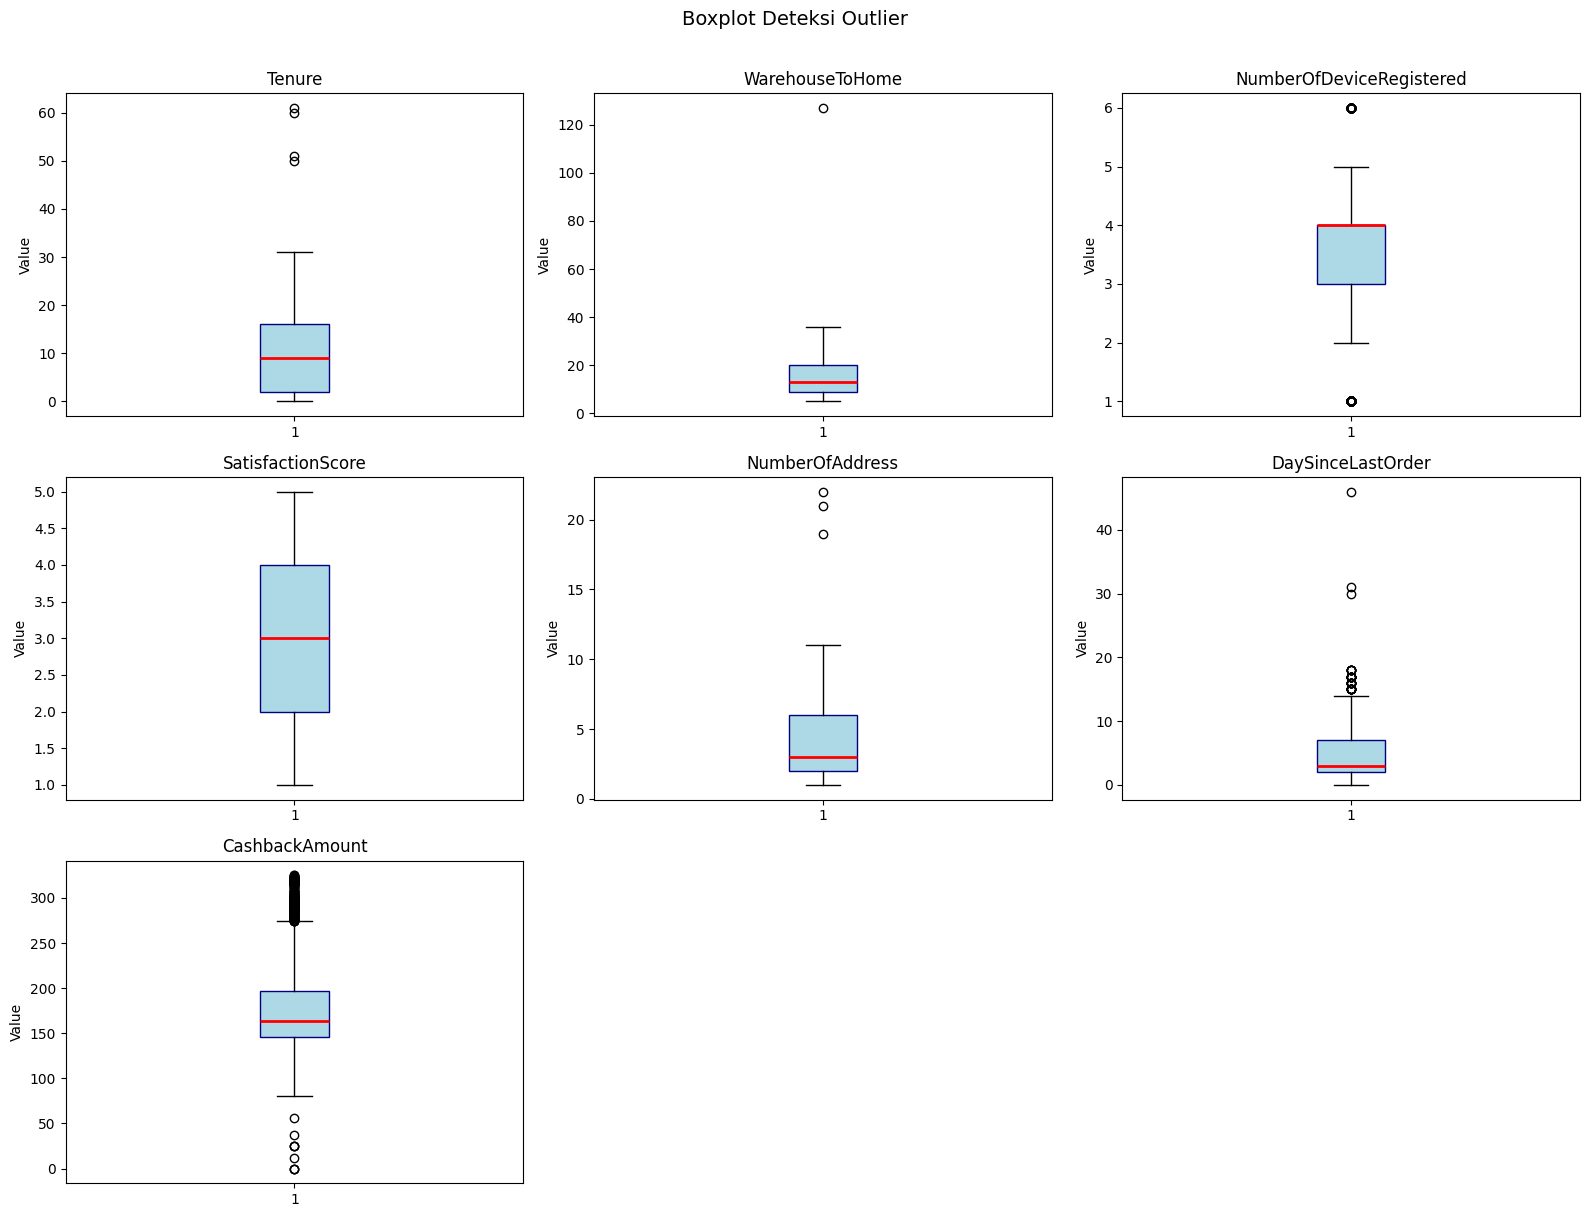

In [12]:
# --- Visualisasi Outlier (Boxplot) ---
num_cols = df.select_dtypes(include='number').drop(columns=['Churn', 'Complain'], errors='ignore').columns.tolist()

n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_ylabel('Value')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Deteksi Outlier', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

> **Mengapa menggunakan metode IQR untuk mendeteksi outlier?**
>
> Metode **IQR (Interquartile Range)** adalah cara deteksi outlier yang paling umum karena:
>
> - **Robust** — tidak menggunakan mean atau std yang bisa terpengaruh outlier itu sendiri
> - **Non-parametrik** — tidak mengasumsikan distribusi normal pada data
> - **Standar industri** — threshold `Q1 - 1.5 x IQR` dan `Q3 + 1.5 x IQR` adalah batas yang telah teruji secara statistik
>
> Kolom `Churn` dan `Complain` dikecualikan karena merupakan variabel biner (0/1) yang memang hanya memiliki dua nilai dan tidak perlu penanganan outlier.

In [13]:
# --- Deteksi Outlier dengan IQR ---
print('=== JUMLAH OUTLIER PER KOLOM (IQR Method) ===')
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                             'Lower Bound': lower, 'Upper Bound': upper,
                             'Jumlah Outlier': n_out}
    print(f'  [{col}]: {n_out} outlier | Batas bawah={lower:.2f}, Batas atas={upper:.2f}')

outlier_df = pd.DataFrame(outlier_summary).T
display(outlier_df)

=== JUMLAH OUTLIER PER KOLOM (IQR Method) ===
  [Tenure]: 4 outlier | Batas bawah=-19.00, Batas atas=37.00
  [WarehouseToHome]: 1 outlier | Batas bawah=-7.50, Batas atas=36.50
  [NumberOfDeviceRegistered]: 226 outlier | Batas bawah=1.50, Batas atas=5.50
  [SatisfactionScore]: 0 outlier | Batas bawah=-1.00, Batas atas=7.00
  [NumberOfAddress]: 3 outlier | Batas bawah=-4.00, Batas atas=12.00
  [DaySinceLastOrder]: 40 outlier | Batas bawah=-5.50, Batas atas=14.50
  [CashbackAmount]: 253 outlier | Batas bawah=69.02, Batas atas=274.00


,Q1,Q3,IQR,Lower Bound,Upper Bound,Jumlah Outlier
Tenure,2.0000,16.0000,14.000,-19.000,37.000,4.0
WarehouseToHome,9.0000,20.0000,11.000,-7.500,36.500,1.0
NumberOfDeviceRegistered,3.0000,4.0000,1.000,1.500,5.500,226.0
SatisfactionScore,2.0000,4.0000,2.000,-1.000,7.000,0.0
NumberOfAddress,2.0000,6.0000,4.000,-4.000,12.000,3.0
DaySinceLastOrder,2.0000,7.0000,5.000,-5.500,14.500,40.0
CashbackAmount,145.8925,197.1375,51.245,69.025,274.005,253.0


In [14]:
# --- Penanganan Outlier: Capping (Winsorization) ---
# Metode capping lebih aman dari drop karena tidak kehilangan data

df_before_out = df.shape[0]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

print(f'✅ Outlier berhasil di-cap menggunakan metode IQR Winsorization')
print(f'Shape data setelah handling outlier: {df.shape}')

✅ Outlier berhasil di-cap menggunakan metode IQR Winsorization
Shape data setelah handling outlier: (3270, 11)


> **Mengapa perlu verifikasi ulang dengan boxplot setelah penanganan outlier?**
>
> Verifikasi pasca-handling adalah bagian kritis dari proses cleaning yang sering dilewatkan. Tujuannya:
>
> - **Konfirmasi keberhasilan** — memastikan outlier benar-benar sudah tertangani dan tidak ada nilai ekstrem yang tersisa
> - **Mendeteksi masalah baru** — kadang setelah capping, distribusi berubah sehingga muncul ketidakwajaran baru
> - **Dokumentasi visual** — menjadi bukti bahwa data yang akan masuk ke model sudah bersih
>
> Perbandingan boxplot sebelum (warna biru) dan sesudah (warna hijau) memudahkan reviewer memahami transformasi yang terjadi.

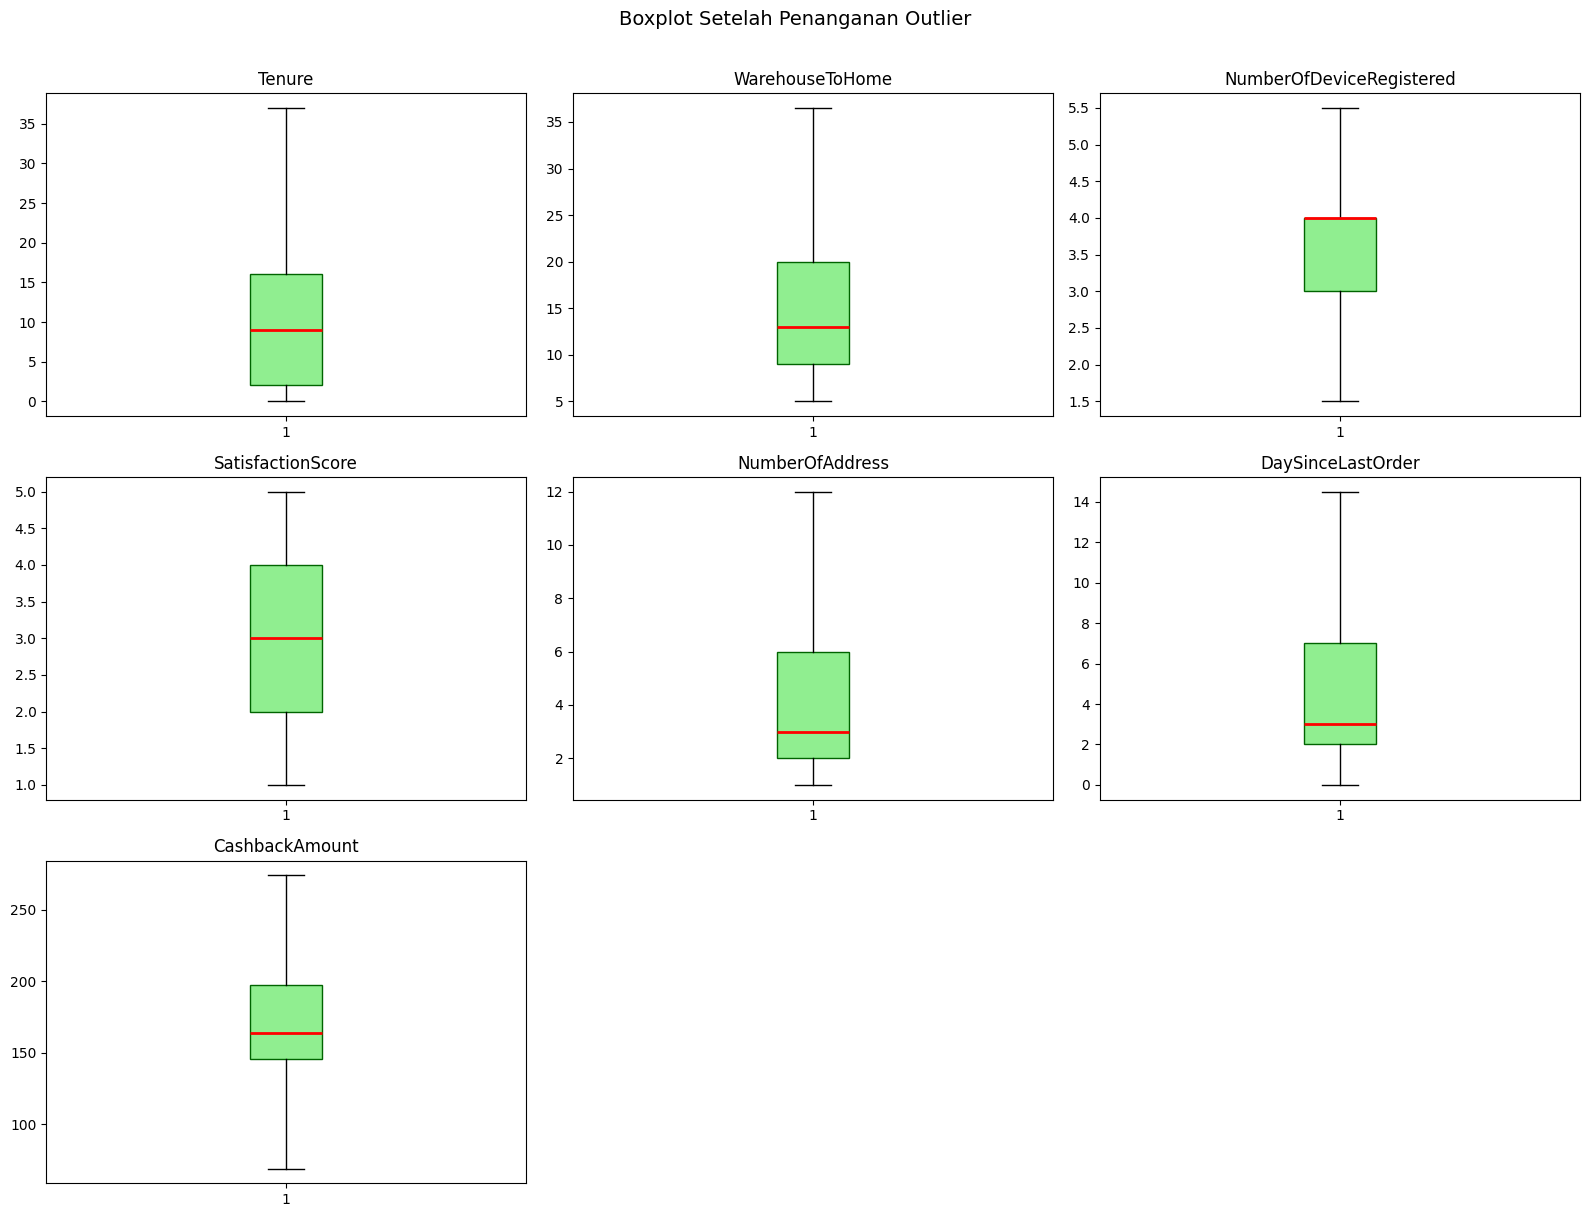

In [15]:
# --- Verifikasi Boxplot Setelah Handling ---
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}', fontsize=12)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Setelah Penanganan Outlier', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# --- Ringkasan Data Cleaning ---
print('=' * 45)
print('       RINGKASAN DATA CLEANING')
print('=' * 45)
print(f'Shape awal             : {df_raw.shape}')
print(f'Shape setelah cleaning : {df.shape}')
print(f'Missing values tersisa : {df.isnull().sum().sum()}')
print(f'Duplikat tersisa       : {df.duplicated().sum()}')
print('=' * 45)

       RINGKASAN DATA CLEANING
Shape awal             : (3941, 11)
Shape setelah cleaning : (3270, 11)
Missing values tersisa : 476
Duplikat tersisa       : 1


---
# ⚙️ BAGIAN 2 — DATA PREPROCESSING

## 2.1 Encoding

> **Mengapa kolom kategorikal perlu di-encode?**
>
> Algoritma machine learning, termasuk Random Forest dan XGBoost, **hanya dapat memproses angka**. Kolom bertipe `object` (teks) tidak bisa langsung digunakan sebagai input model. Oleh karena itu, kita perlu mengubah kategori menjadi representasi numerik.
>
> Langkah identifikasi ini penting untuk:
> - Mengetahui **kolom mana** yang akan di-encode
> - Melihat **jumlah kategori unik** di setiap kolom — membantu memilih metode encoding yang tepat
> - Memahami **distribusi** setiap kategori — kolom dengan kardinalitas tinggi mungkin perlu penanganan khusus

In [17]:
# --- Identifikasi Kolom Kategorik ---
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Kolom kategorik yang akan di-encode: {cat_cols}')

for col in cat_cols:
    print(f'\n[{col}] - {df[col].nunique()} kategori:')
    print(df[col].value_counts())

Kolom kategorik yang akan di-encode: ['PreferedOrderCat', 'MaritalStatus']

[PreferedOrderCat] - 5 kategori:
PreferedOrderCat
Laptop & Accessory    1213
Mobile Phone          1183
Fashion                484
Grocery                241
Others                 149
Name: count, dtype: int64

[MaritalStatus] - 3 kategori:
MaritalStatus
Married     1686
Single      1008
Divorced     576
Name: count, dtype: int64


> **Mengapa memilih One-Hot Encoding (OHE) dan bukan Label Encoding?**
>
> Ada dua metode encoding utama:
>
> | Metode | Cara Kerja | Kapan Digunakan |
> |--------|-----------|----------------|
> | **Label Encoding** | Ubah kategori menjadi angka (0, 1, 2...) | Kolom **ordinal** yang memiliki urutan jelas (Rendah, Sedang, Tinggi) |
> | **One-Hot Encoding** | Buat kolom biner baru per kategori | Kolom **nominal** tanpa urutan |
>
> `MaritalStatus` dan `PreferedOrderCat` adalah kolom **nominal** — tidak ada urutan seperti `Single` lebih besar dari `Married`. Menggunakan Label Encoding pada kolom nominal akan membuat model salah menginterpretasikan ada hierarki di antara kategori.
>
> Kolom boolean hasil OHE dikonversi ke integer (0/1) agar kompatibel dengan semua library.

In [18]:
# --- Label Encoding untuk Kolom Ordinal / Binary ---
# MaritalStatus: tidak ada urutan → gunakan One-Hot Encoding
# PreferedOrderCat: tidak ada urutan → gunakan One-Hot Encoding

df_encoded = df.copy()

# One-Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=cat_cols, drop_first=False)

# Konversi bool → int
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f'Shape sebelum encoding: {df.shape}')
print(f'Shape setelah encoding: {df_encoded.shape}')
print(f'\nKolom baru setelah encoding:')
print([c for c in df_encoded.columns if c not in df.columns])
df_encoded.head()

Shape sebelum encoding: (3270, 11)
Shape setelah encoding: (3270, 17)

Kolom baru setelah encoding:
['PreferedOrderCat_Fashion', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single']


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,PreferedOrderCat_Fashion,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,15.0,29.0,4.0,3,2,0,7.0,143.320,0,0,0,1,0,0,0,0,1
1,7.0,25.0,4.0,1,2,0,7.0,129.290,0,0,0,0,1,0,0,1,0
2,27.0,13.0,3.0,1,5,0,7.0,168.540,0,0,0,1,0,0,0,1,0
3,20.0,25.0,4.0,3,7,0,NaN,230.270,0,1,0,0,0,0,1,0,0
4,30.0,15.0,4.0,4,8,0,8.0,274.005,0,0,0,0,0,1,0,0,1


## 2.2 Splitting Dataset

> **Mengapa kita memisahkan fitur (X) dan target (y) sebelum splitting?**
>
> Pemisahan X dan y adalah fondasi dari supervised learning:
>
> - **X (fitur/prediktor)** — semua kolom yang digunakan model untuk belajar pola
> - **y (target/label)** — kolom yang ingin diprediksi, yaitu `Churn`
>
> Visualisasi distribusi kelas target **sebelum split** penting untuk mendeteksi **class imbalance**. Dataset churn biasanya imbalanced — pelanggan yang tidak churn jauh lebih banyak dari yang churn. Mengetahui ini di awal menentukan strategi yang akan digunakan seperti SMOTE atau class_weight.

Fitur (X)  : (3270, 16)
Target (y) : (3270,)

Distribusi target SEBELUM split:
Churn
0    2736
1     534
Name: count, dtype: int64
Churn
0    83.67%
1    16.33%
Name: proportion, dtype: str


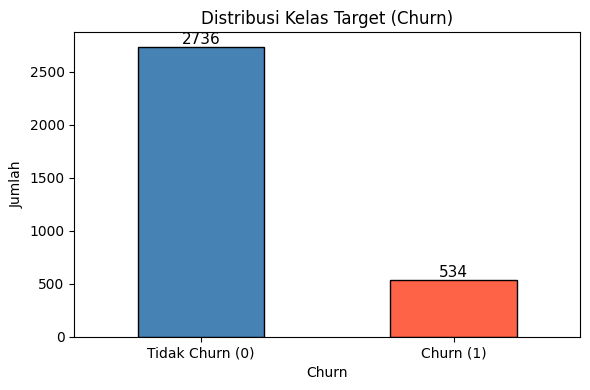

In [19]:
# --- Pisah Fitur dan Target ---
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print(f'Fitur (X)  : {X.shape}')
print(f'Target (y) : {y.shape}')
print(f'\nDistribusi target SEBELUM split:')
print(y.value_counts())
print(y.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Visualisasi distribusi kelas
fig, ax = plt.subplots(figsize=(6, 4))
y.value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Distribusi Kelas Target (Churn)')
ax.set_xticklabels(['Tidak Churn (0)', 'Churn (1)'], rotation=0)
ax.set_ylabel('Jumlah')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

> **Mengapa menggunakan `stratify=y` pada Train-Test Split?**
>
> Parameter `stratify=y` memastikan proporsi kelas target (Churn vs Tidak Churn) **terjaga sama** di training set dan test set.
>
> Tanpa stratifikasi, split acak bisa menghasilkan test set yang hampir tidak memiliki sampel kelas minoritas (pelanggan churn), sehingga evaluasi model menjadi tidak representatif.
>
> - **80% training** — data yang digunakan model untuk belajar
> - **20% test** — data yang tidak pernah dilihat model, digunakan hanya untuk evaluasi akhir
> - `random_state=42` — memastikan hasil yang dapat direproduksi (*reproducibility*)

In [20]:
# --- Train-Test Split (80:20, Stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # pastikan proporsi kelas terjaga
)

print(f'Training set   : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set       : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nDistribusi Churn di Training:')
print(y_train.value_counts())
print(f'\nDistribusi Churn di Test:')
print(y_test.value_counts())

Training set   : 2,616 baris (80.0%)
Test set       : 654 baris (20.0%)

Distribusi Churn di Training:
Churn
0    2189
1     427
Name: count, dtype: int64

Distribusi Churn di Test:
Churn
0    547
1    107
Name: count, dtype: int64


## 2.3 Scaling

> **Mengapa fitur numerik perlu di-scale? Dan mengapa hanya fit pada training data?**
>
> **Alasan scaling:**
> - Fitur dengan skala berbeda (misal: `CashbackAmount` 0-300 vs `SatisfactionScore` 1-5) akan membuat model yang sensitif terhadap skala cenderung bias ke fitur dengan nilai lebih besar
> - Meskipun tree-based models (RF, XGBoost) tidak sensitif terhadap skala, scaling dilakukan untuk konsistensi pipeline
>
> **Mengapa fit HANYA pada training data:**
> - Jika scaler di-fit pada seluruh data (termasuk test), informasi dari test set bocor ke proses training — ini disebut **data leakage**
> - Data leakage menyebabkan evaluasi model terlihat lebih baik dari kenyataannya
> - Kolom dummy biner (nilai hanya 0 atau 1) dikecualikan dari scaling karena sudah berada di rentang yang sama

In [21]:
# --- StandardScaler pada fitur numerik ---

num_features = X_train.select_dtypes(include='number').columns.tolist()
# Hapus kolom dummy (nilai 0/1) dari scaling
cols_to_scale = [c for c in num_features
                 if X_train[c].max() > 1 or X_train[c].min() < 0]

print(f'Kolom yang di-scale: {cols_to_scale}')

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print('\n✅ Scaling selesai (fit pada train, transform pada test)')
print(X_train_scaled[cols_to_scale].describe().T[['mean', 'std', 'min', 'max']])

Kolom yang di-scale: ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'DaySinceLastOrder', 'CashbackAmount']

✅ Scaling selesai (fit pada train, transform pada test)
                                  mean       std       min       max
Tenure                    1.026466e-16  1.000201 -1.202692  3.105171
WarehouseToHome           3.752368e-17  1.000199 -1.250314  2.508189
NumberOfDeviceRegistered -1.222264e-16  1.000191 -2.374387  1.949216
SatisfactionScore         1.018553e-16  1.000191 -1.451960  1.435953
NumberOfAddress           7.333583e-17  1.000191 -1.250226  3.011384
DaySinceLastOrder        -1.035190e-16  1.000202 -1.293166  2.839879
CashbackAmount           -3.340855e-16  1.000191 -2.391956  2.165570


## 2.4 Balancing (SMOTE)

> **Mengapa class imbalance berbahaya dan mengapa SMOTE dipilih sebagai solusinya?**
>
> **Masalah Class Imbalance:**
> Dataset churn biasanya sangat imbalanced — misalnya 83% tidak churn vs 17% churn. Model yang dilatih pada data imbalanced cenderung:
> - Memprediksi **selalu kelas mayoritas** (tidak churn) dan tetap mendapat akurasi tinggi
> - **Gagal mendeteksi pelanggan yang benar-benar churn** — justru yang paling merugikan bisnis
>
> **Mengapa SMOTE (Synthetic Minority Over-sampling Technique)?**
> - SMOTE membuat **sampel sintetis baru** dari kelas minoritas (churn) dengan interpolasi antar tetangga terdekat, bukan sekadar menduplikasi data
> - Menghasilkan data yang lebih beragam dibanding simple oversampling
>
> **Penting:** SMOTE **hanya diterapkan pada training data**, bukan test data. Test set harus tetap mencerminkan distribusi dunia nyata agar evaluasi model valid dan tidak bias.

In [22]:
# --- SMOTE: Synthetic Minority Over-sampling Technique ---

print('Distribusi SEBELUM SMOTE:')
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print('\nDistribusi SETELAH SMOTE:')
bal_counts = pd.Series(y_train_bal).value_counts()
print(bal_counts)

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y_train.value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Sebelum SMOTE')
axes[0].set_xticklabels(['Tidak Churn', 'Churn'], rotation=0)

bal_counts.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('Setelah SMOTE')
axes[1].set_xticklabels(['Tidak Churn', 'Churn'], rotation=0)

plt.suptitle('Balancing dengan SMOTE', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\n✅ Training data setelah SMOTE: {X_train_bal.shape[0]:,} baris')

Distribusi SEBELUM SMOTE:
Churn
0    2189
1     427
Name: count, dtype: int64


ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

---
# 🔧 BAGIAN 3 — HYPERPARAMETER TUNING

## 3.1 Baseline Model Comparison

> **Mengapa perlu membandingkan model baseline sebelum hyperparameter tuning?**
>
> Baseline comparison dengan **Cross-Validation (CV)** sebelum tuning berfungsi sebagai:
>
> - **Titik referensi** — mengetahui performa model dengan parameter default. Jika setelah tuning performanya tidak jauh berbeda, berarti parameter bukan bottleneck utama
> - **Pemilihan model** — dari beberapa kandidat (Logistic Regression, Random Forest, Gradient Boosting, XGBoost), kita bisa memfokuskan tuning pada 1-2 model terbaik
> - **Efisiensi** — hyperparameter tuning membutuhkan waktu komputasi besar; memilih model yang tepat dulu menghemat waktu
>
> **StratifiedKFold** digunakan agar setiap fold mempertahankan proporsi kelas, dan **F1-Score** sebagai metrik karena lebih representatif untuk data imbalanced dibanding akurasi.

=== BASELINE CROSS-VALIDATION (5-Fold, Metric: F1) ===
Logistic Regression       | F1 Mean: 0.8298 | Std: 0.0079
Random Forest             | F1 Mean: 0.9473 | Std: 0.0045
Gradient Boosting         | F1 Mean: 0.9135 | Std: 0.0046
XGBoost                   | F1 Mean: 0.9512 | Std: 0.0040


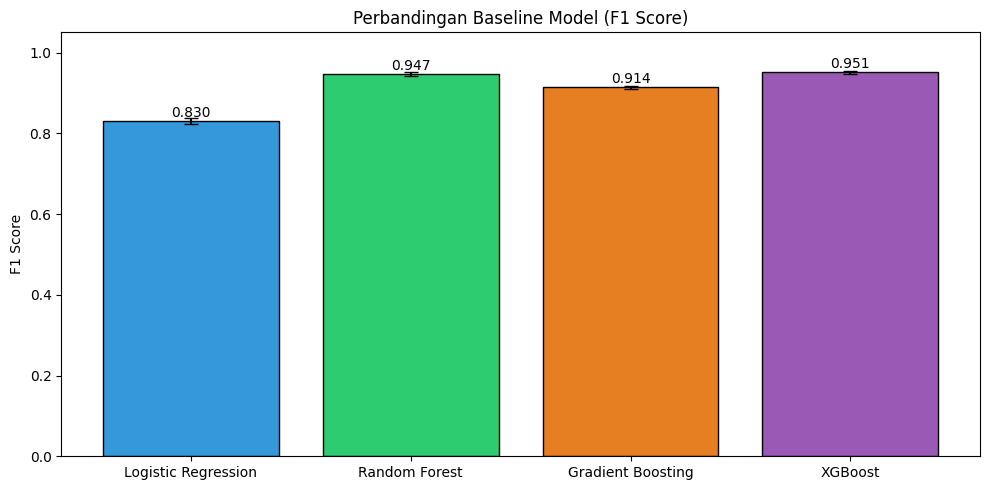

In [ ]:
# --- Perbandingan Model Baseline sebelum Tuning ---
from sklearn.model_selection import cross_val_score

baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(random_state=42),
    'XGBoost'            : XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('=== BASELINE CROSS-VALIDATION (5-Fold, Metric: F1) ===')
baseline_results = {}

for name, model in baseline_models.items():
    scores = cross_val_score(model, X_train_bal, y_train_bal,
                             cv=cv, scoring='f1', n_jobs=-1)
    baseline_results[name] = scores
    print(f'{name:<25} | F1 Mean: {scores.mean():.4f} | Std: {scores.std():.4f}')

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
names = list(baseline_results.keys())
means = [v.mean() for v in baseline_results.values()]
stds  = [v.std()  for v in baseline_results.values()]

bars = ax.bar(names, means, yerr=stds, capsize=5,
              color=['#3498db','#2ecc71','#e67e22','#9b59b6'], edgecolor='black')
ax.set_title('Perbandingan Baseline Model (F1 Score)')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{mean:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 3.2 Parameter Grid & Cross-Validation

> **Mengapa menggunakan `RandomizedSearchCV` bukan `GridSearchCV`?**
>
> Ada dua pendekatan utama dalam hyperparameter search:
>
> | Metode | Cara Kerja | Keunggulan | Kelemahan |
> |--------|-----------|------------|----------|
> | **GridSearchCV** | Coba **semua kombinasi** parameter | Menjamin menemukan kombinasi terbaik dalam grid | Sangat lambat jika parameter banyak |
> | **RandomizedSearchCV** | Coba **kombinasi acak** sebanyak `n_iter` | Jauh lebih cepat, sering menemukan hasil hampir setara | Tidak exhaustive |
>
> Dengan banyaknya kombinasi parameter yang mungkin, `GridSearchCV` akan terlalu lambat. `RandomizedSearchCV` dengan `n_iter=30` mencoba 30 kombinasi acak yang cukup untuk menemukan parameter yang baik secara efisien.
>
> Parameter `class_weight` dimasukkan ke dalam grid sebagai salah satu cara untuk membantu model menangani class imbalance.

In [ ]:
# --- Hyperparameter Tuning: Random Forest ---

rf_param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
    'class_weight'     : ['balanced', None]
}

rf_base = RandomForestClassifier(random_state=42)

rf_search = RandomizedSearchCV(
    estimator   = rf_base,
    param_distributions = rf_param_grid,
    n_iter      = 30,          # coba 30 kombinasi random
    cv          = cv,          # StratifiedKFold 5-fold
    scoring     = 'f1',
    n_jobs      = -1,
    random_state= 42,
    verbose     = 1
)

print('🔍 Menjalankan Hyperparameter Tuning untuk Random Forest...')
rf_search.fit(X_train_bal, y_train_bal)

print(f'\n✅ Best Score (F1): {rf_search.best_score_:.4f}')
print(f'Best Parameters  :')
for k, v in rf_search.best_params_.items():
    print(f'  {k:<25}: {v}')

🔍 Menjalankan Hyperparameter Tuning untuk Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best Score (F1): 0.9442
Best Parameters  :
  n_estimators             : 100
  min_samples_split        : 5
  min_samples_leaf         : 1
  max_features             : log2
  max_depth                : None
  class_weight             : balanced


> **Apa saja hyperparameter kunci XGBoost yang di-tune dan mengapa?**
>
> - **`n_estimators`** — jumlah pohon (boosting rounds). Lebih banyak pohon lebih akurat tapi lebih lama dan bisa overfit
> - **`max_depth`** — kedalaman maksimum setiap pohon. Nilai kecil menyebabkan underfitting; nilai besar menyebabkan overfitting
> - **`learning_rate`** — seberapa besar kontribusi setiap pohon baru. Nilai kecil lebih stabil tapi butuh lebih banyak pohon
> - **`subsample`** — proporsi data yang digunakan per boosting round. Nilai kurang dari 1.0 membantu mencegah overfitting
> - **`colsample_bytree`** — proporsi fitur yang digunakan per pohon. Mirip `max_features` di Random Forest
> - **`min_child_weight`** — jumlah minimum sampel di daun pohon. Nilai lebih besar mencegah overfitting
> - **`gamma`** — minimum loss reduction untuk split. Nilai lebih dari 0 membuat model lebih konservatif

In [ ]:
# --- Hyperparameter Tuning: XGBoost ---

xgb_param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5],
    'learning_rate' : [0.01, 0.1],
    'subsample'     : [0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma'         : [0, 0.1, 0.2]
}

xgb_base = XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0)

xgb_search = RandomizedSearchCV(
    estimator   = xgb_base,
    param_distributions = xgb_param_grid,
    n_iter      = 30,
    cv          = cv,
    scoring     = 'f1',
    n_jobs      = -1,
    random_state= 42,
    verbose     = 1
)

print('🔍 Menjalankan Hyperparameter Tuning untuk XGBoost...')
xgb_search.fit(X_train_bal, y_train_bal)

print(f'\n✅ Best Score (F1): {xgb_search.best_score_:.4f}')
print(f'Best Parameters  :')
for k, v in xgb_search.best_params_.items():
    print(f'  {k:<25}: {v}')

🔍 Menjalankan Hyperparameter Tuning untuk XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best Score (F1): 0.9487
Best Parameters  :
  subsample                : 1.0
  n_estimators             : 200
  min_child_weight         : 1
  max_depth                : 5
  learning_rate            : 0.1
  gamma                    : 0
  colsample_bytree         : 0.7


## 3.3 Retrained Model dengan Best Parameters

> **Mengapa perlu retrain ulang model setelah mendapat best parameters?**
>
> Setelah `RandomizedSearchCV`, `best_estimator_` sudah dilatih pada salah satu fold CV, bukan pada **seluruh training data**. Retrain ulang dilakukan dengan:
>
> - **Parameter terbaik** yang ditemukan oleh search
> - **Seluruh `X_train_bal`** (data training yang sudah di-SMOTE)
>
> Mengapa ini penting? Semakin banyak data training, semakin baik model belajar pola. CV hanya menggunakan sebagian data di setiap fold, jadi model final harus dilatih pada semua data training yang tersedia untuk performa maksimal.

In [ ]:
# --- Retrain dengan best params pada SELURUH training data ---

best_rf  = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

# Retrain ulang secara eksplisit
best_rf.fit(X_train_bal, y_train_bal)
best_xgb.fit(X_train_bal, y_train_bal)

print('✅ Model berhasil di-retrain dengan parameter terbaik:')
print(f'  Random Forest : {rf_search.best_params_}')
print(f'  XGBoost       : {xgb_search.best_params_}')

✅ Model berhasil di-retrain dengan parameter terbaik:
  Random Forest : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced'}
  XGBoost       : {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}


## 3.4 Cross-Validation pada Model Tuned

> **Mengapa perlu Cross-Validation ulang setelah tuning?**
>
> CV setelah tuning berfungsi untuk:
>
> - **Validasi stabilitas** — melihat apakah performa model konsisten di setiap fold atau sangat bervariasi (std tinggi berarti model tidak stabil)
> - **Membandingkan dengan baseline** — apakah tuning benar-benar memberikan peningkatan yang signifikan?
> - **Estimasi performa yang lebih andal** — satu split train/test bisa menyesatkan; CV dengan 5 fold memberikan estimasi yang lebih robust
>
> Scores per-fold ditampilkan untuk memastikan tidak ada satu fold yang hasilnya jauh berbeda dari lainnya, yang bisa mengindikasikan overfitting pada fold tertentu.

In [ ]:
# --- Cross-Validation setelah Tuning ---
print('=== CROSS-VALIDATION SETELAH TUNING (5-Fold) ===')

tuned_models = {
    'Random Forest (Tuned)': best_rf,
    'XGBoost (Tuned)'      : best_xgb
}

tuned_cv_results = {}
for name, model in tuned_models.items():
    scores = cross_val_score(model, X_train_bal, y_train_bal,
                             cv=cv, scoring='f1', n_jobs=-1)
    tuned_cv_results[name] = scores
    print(f'{name:<30} | F1 Mean: {scores.mean():.4f} | Std: {scores.std():.4f}')
    print(f'  Scores per-fold: {[round(s,4) for s in scores]}')

=== CROSS-VALIDATION SETELAH TUNING (5-Fold) ===
Random Forest (Tuned)          | F1 Mean: 0.9442 | Std: 0.0057
  Scores per-fold: [np.float64(0.9431), np.float64(0.9373), np.float64(0.9443), np.float64(0.9545), np.float64(0.942)]
XGBoost (Tuned)                | F1 Mean: 0.9487 | Std: 0.0036
  Scores per-fold: [np.float64(0.9499), np.float64(0.9424), np.float64(0.9531), np.float64(0.9479), np.float64(0.9501)]


---
# 📊 BAGIAN 4 — FINAL EVALUATION

## 4.1 Evaluasi pada Test Set

> **Mengapa kita perlu beberapa metrik evaluasi, tidak cukup hanya akurasi?**
>
> Untuk dataset **imbalanced** seperti churn, akurasi saja sangat menyesatkan:
> - Model yang **selalu memprediksi tidak churn** akan mendapat akurasi 83% tanpa belajar apapun!
>
> | Metrik | Apa yang Diukur | Mengapa Penting untuk Churn |
> |--------|----------------|-----------------------------|
> | **Accuracy** | Persentase prediksi benar | Tidak cukup untuk data imbalanced |
> | **Precision** | Dari yang diprediksi churn, berapa persen benar-benar churn | Mengurangi intervensi sia-sia pada pelanggan yang tidak akan churn |
> | **Recall** | Dari yang benar-benar churn, berapa persen berhasil terdeteksi | Paling kritis — jangan sampai pelanggan churn tidak terdeteksi |
> | **F1 Score** | Harmonic mean Precision dan Recall | Keseimbangan antara Precision dan Recall |
> | **ROC-AUC** | Kemampuan model membedakan dua kelas | Robust terhadap imbalance |
>
> Fungsi `evaluate_model` dibuat agar evaluasi dapat dijalankan secara konsisten dan mudah diulang untuk semua model.

In [ ]:
# --- Prediksi pada Test Set ---
def evaluate_model(name, model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_prob  = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1 Score' : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob)
    }
    return metrics, y_pred, y_prob


models_to_eval = {
    'Random Forest (Tuned)': best_rf,
    'XGBoost (Tuned)'      : best_xgb
}

eval_results = {}
preds_dict   = {}

print('=== FINAL EVALUATION PADA TEST SET ===')
for name, model in models_to_eval.items():
    metrics, y_pred, y_prob = evaluate_model(name, model, X_test_scaled, y_test)
    eval_results[name] = metrics
    preds_dict[name]   = (y_pred, y_prob)
    print(f'\n[{name}]')
    for k, v in metrics.items():
        print(f'  {k:<12}: {v:.4f}')

eval_df = pd.DataFrame(eval_results).T
print('\n=== TABEL PERBANDINGAN AKHIR ===')
display(eval_df.style.highlight_max(axis=0, color='lightgreen'))

=== FINAL EVALUATION PADA TEST SET ===

[Random Forest (Tuned)]
  Accuracy    : 0.9021
  Precision   : 0.6720
  Recall      : 0.7850
  F1 Score    : 0.7241
  ROC-AUC     : 0.9509

[XGBoost (Tuned)]
  Accuracy    : 0.9128
  Precision   : 0.7358
  Recall      : 0.7290
  F1 Score    : 0.7324
  ROC-AUC     : 0.9565

=== TABEL PERBANDINGAN AKHIR ===


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest (Tuned),0.902141,0.672000,0.785047,0.724138,0.950913
XGBoost (Tuned),0.912844,0.735849,0.728972,0.732394,0.956500


## 4.2 Classification Report

> **Apa informasi yang diberikan Classification Report?**
>
> Classification report memberikan breakdown metrik **per kelas** (Tidak Churn dan Churn):
>
> - **Precision per kelas** — dari semua yang diprediksi sebagai kelas X, berapa yang benar?
> - **Recall per kelas** — dari semua yang sebenarnya kelas X, berapa yang berhasil dideteksi?
> - **F1-Score per kelas** — harmonic mean precision dan recall per kelas
> - **Support** — jumlah sampel aktual per kelas di test set
>
> Perhatikan khususnya **Recall kelas Churn (1)** — inilah metrik yang paling kritis dari sisi bisnis. Recall rendah berarti banyak pelanggan yang akan churn tidak terdeteksi oleh model, sehingga tidak ada tindakan retensi yang bisa diambil.

In [ ]:
for name, model in models_to_eval.items():
    y_pred, _ = preds_dict[name]
    print(f'\n--- Classification Report: {name} ---')
    print(classification_report(y_test, y_pred,
                                 target_names=['Tidak Churn (0)', 'Churn (1)']))


--- Classification Report: Random Forest (Tuned) ---
                 precision    recall  f1-score   support

Tidak Churn (0)       0.96      0.93      0.94       547
      Churn (1)       0.67      0.79      0.72       107

       accuracy                           0.90       654
      macro avg       0.81      0.86      0.83       654
   weighted avg       0.91      0.90      0.91       654


--- Classification Report: XGBoost (Tuned) ---
                 precision    recall  f1-score   support

Tidak Churn (0)       0.95      0.95      0.95       547
      Churn (1)       0.74      0.73      0.73       107

       accuracy                           0.91       654
      macro avg       0.84      0.84      0.84       654
   weighted avg       0.91      0.91      0.91       654



## 4.3 Confusion Matrix

> **Mengapa Confusion Matrix penting untuk memahami performa model secara detail?**
>
> Confusion matrix menampilkan **empat jenis prediksi** secara visual:
>
> |  | Prediksi: Tidak Churn | Prediksi: Churn |
> |--|----------------------|-----------------|
> | **Aktual: Tidak Churn** | True Negative (TN) — benar tidak churn | False Positive (FP) — salah diprediksi churn |
> | **Aktual: Churn** | False Negative (FN) — salah, seharusnya churn | True Positive (TP) — benar churn terdeteksi |
>
> **False Negative (FN)** adalah kesalahan paling mahal — pelanggan yang *akan* churn tapi *tidak terdeteksi* oleh model. Akibatnya tidak ada tindakan retensi yang dilakukan dan pelanggan hilang.
>
> Menampilkan dua model berdampingan memudahkan perbandingan langsung antara Random Forest dan XGBoost dalam hal distribusi error masing-masing.

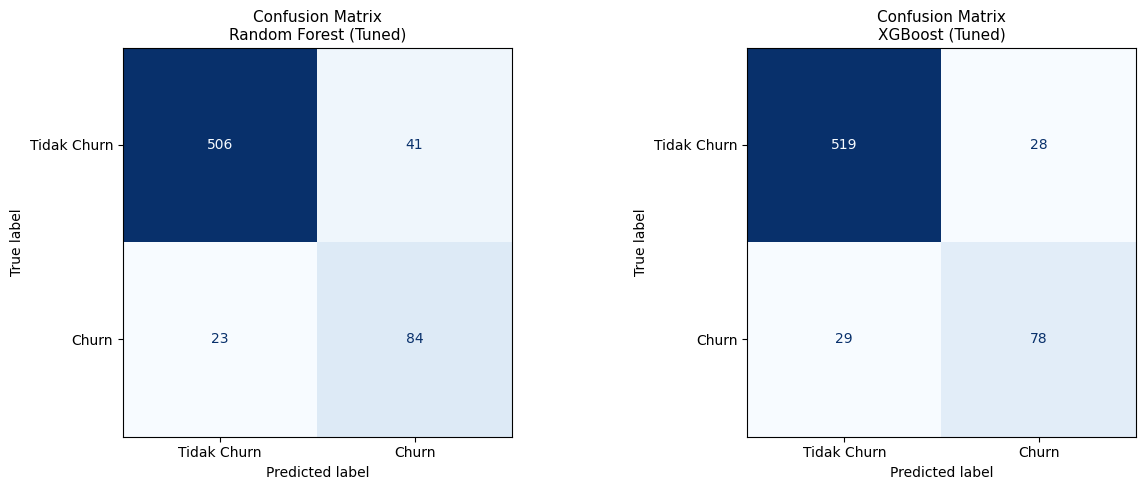

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, model) in zip(axes, models_to_eval.items()):
    y_pred, _ = preds_dict[name]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Tidak Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=11)

plt.tight_layout()
plt.show()

## 4.4 ROC Curve

> **Apa itu ROC Curve dan mengapa penting untuk evaluasi model?**
>
> **ROC (Receiver Operating Characteristic) Curve** memplot **True Positive Rate (Recall)** vs **False Positive Rate** pada berbagai threshold klasifikasi.
>
> - **AUC (Area Under Curve)** — semakin mendekati 1.0, semakin baik model membedakan kedua kelas
> - AUC = 0.5 — model tidak lebih baik dari tebakan acak (garis diagonal)
> - AUC = 1.0 — model sempurna
>
> ROC Curve berguna karena:
> - **Tidak bergantung pada threshold** — mengevaluasi model secara keseluruhan, bukan hanya pada threshold default 0.5
> - **Robust terhadap class imbalance** — berbeda dengan akurasi
> - Membantu memilih **threshold optimal** sesuai kebutuhan bisnis, misalnya memprioritaskan Recall tinggi untuk menangkap sebanyak mungkin pelanggan churn

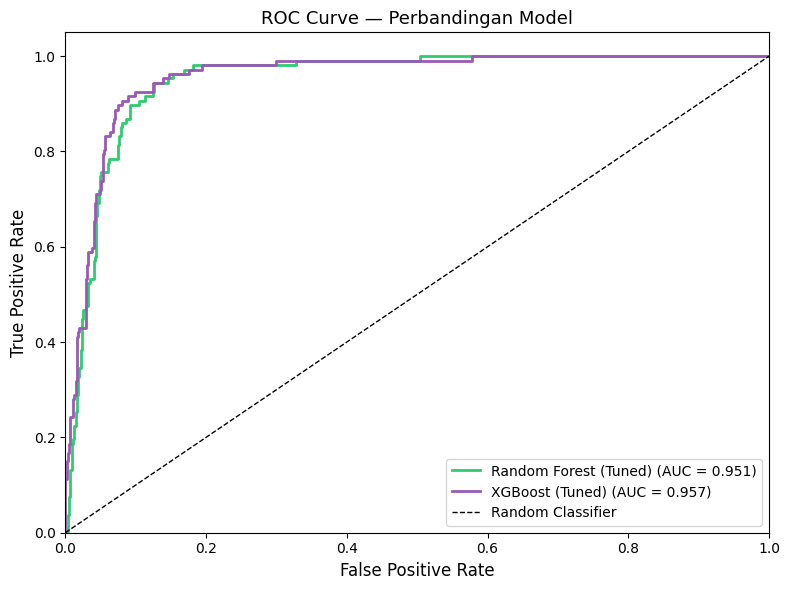

In [ ]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2ecc71', '#9b59b6']

for (name, model), color in zip(models_to_eval.items(), colors):
    _, y_prob = preds_dict[name]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Perbandingan Model', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## 4.5 Feature Importance

> **Mengapa Feature Importance penting dari perspektif bisnis?**
>
> Feature importance mengungkap **fitur mana yang paling berpengaruh** dalam prediksi churn. Informasi ini bermanfaat untuk:
>
> - **Insight bisnis** — fitur dengan importance tinggi menunjukkan faktor utama yang mendorong pelanggan churn. Tim bisnis dapat fokus memperbaiki faktor ini, misalnya jika `Tenure` paling penting maka program retensi difokuskan pada pelanggan baru
> - **Feature selection** — fitur dengan importance mendekati 0 dapat dihapus untuk menyederhanakan model tanpa kehilangan performa
> - **Validasi model** — jika fitur yang dianggap penting secara bisnis juga muncul di top feature importance, berarti model masuk akal secara domain
>
> Model terbaik dipilih berdasarkan **ROC-AUC** tertinggi karena metrik ini paling robust untuk mengevaluasi kemampuan diskriminasi model secara keseluruhan.

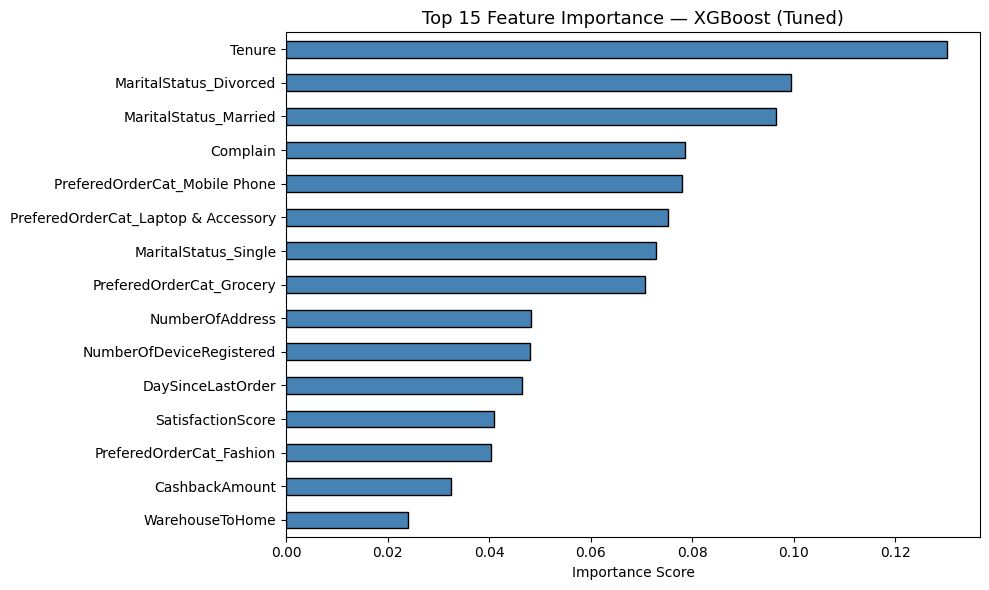

Tenure                                 0.130175
MaritalStatus_Divorced                 0.099444
MaritalStatus_Married                  0.096477
Complain                               0.078512
PreferedOrderCat_Mobile Phone          0.077977
PreferedOrderCat_Laptop & Accessory    0.075234
MaritalStatus_Single                   0.072915
PreferedOrderCat_Grocery               0.070776
NumberOfAddress                        0.048302
NumberOfDeviceRegistered               0.047965
DaySinceLastOrder                      0.046451
SatisfactionScore                      0.040882
PreferedOrderCat_Fashion               0.040317
CashbackAmount                         0.032549
WarehouseToHome                        0.024102
dtype: float32


In [ ]:
# --- Feature Importance dari model terbaik ---
# Gunakan model dengan ROC-AUC tertinggi

best_model_name = eval_df['ROC-AUC'].idxmax()
best_final_model = models_to_eval[best_model_name]

feat_imp = pd.Series(
    best_final_model.feature_importances_,
    index=X_train_bal.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title(f'Top 15 Feature Importance — {best_model_name}', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feat_imp)

## 4.6 Ringkasan Final

> **Mengapa kita membuat Ringkasan Final Pipeline?**
>
> Ringkasan final berfungsi sebagai **executive summary** dari seluruh proses yang telah dilakukan:
>
> - **Dokumentasi lengkap** — merangkum setiap keputusan teknis yang diambil sepanjang notebook dalam format yang ringkas dan mudah dibaca
> - **Reproducibility** — memastikan siapapun yang membaca notebook ini memahami urutan dan metode yang digunakan
> - **Presentasi hasil** — memudahkan komunikasi temuan kepada stakeholder non-teknis
> - **Referensi cepat** — tanpa harus membaca seluruh notebook, pembaca dapat memahami pipeline secara keseluruhan dari ringkasan ini
>
> Ini adalah praktik terbaik dalam penulisan notebook analitik yang profesional.

In [ ]:
print('=' * 55)
print('           📋 RINGKASAN FINAL PIPELINE')
print('=' * 55)

print('\n[DATA CLEANING]')
print(f'  • Missing values   : diimputasi (median / modus)')
print(f'  • Duplikat dihapus : {df_before - df.shape[0]} baris')
print(f'  • Inkonsisten      : standardisasi teks + merge kategori')
print(f'  • Outlier          : capping IQR Winsorization')

print('\n[DATA PREPROCESSING]')
print(f'  • Encoding   : One-Hot Encoding (kategorik)')
print(f'  • Scaling    : StandardScaler (kolom numerik)')
print(f'  • Split      : 80% training / 20% test (stratified)')
print(f'  • Balancing  : SMOTE pada training data')

print('\n[HYPERPARAMETER TUNING]')
print(f'  • Metode     : RandomizedSearchCV (30 iterasi)')
print(f'  • CV         : StratifiedKFold (5 fold)')
print(f'  • Scoring    : F1 Score')
print(f'  • Model      : Random Forest, XGBoost')

print('\n[FINAL EVALUATION — TEST SET]')
for name, metrics in eval_results.items():
    print(f'  [{name}]')
    for k, v in metrics.items():
        print(f'    {k:<12}: {v:.4f}')

print(f'\n🏆 Model Terbaik (ROC-AUC): {eval_df["ROC-AUC"].idxmax()}')
print('=' * 55)

           📋 RINGKASAN FINAL PIPELINE

[DATA CLEANING]
  • Missing values   : diimputasi (median / modus)
  • Duplikat dihapus : 672 baris
  • Inkonsisten      : standardisasi teks + merge kategori
  • Outlier          : capping IQR Winsorization

[DATA PREPROCESSING]
  • Encoding   : One-Hot Encoding (kategorik)
  • Scaling    : StandardScaler (kolom numerik)
  • Split      : 80% training / 20% test (stratified)
  • Balancing  : SMOTE pada training data

[HYPERPARAMETER TUNING]
  • Metode     : RandomizedSearchCV (30 iterasi)
  • CV         : StratifiedKFold (5 fold)
  • Scoring    : F1 Score
  • Model      : Random Forest, XGBoost

[FINAL EVALUATION — TEST SET]
  [Random Forest (Tuned)]
    Accuracy    : 0.9021
    Precision   : 0.6720
    Recall      : 0.7850
    F1 Score    : 0.7241
    ROC-AUC     : 0.9509
  [XGBoost (Tuned)]
    Accuracy    : 0.9128
    Precision   : 0.7358
    Recall      : 0.7290
    F1 Score    : 0.7324
    ROC-AUC     : 0.9565

🏆 Model Terbaik (ROC-AUC): XGBo